# 025 — Training: deterministic architectures x combined_loss alpha sweep

A variant of `020_training.ipynb`. Where `020` trains each deterministic
architecture once, at the project-default loss weight
(`settings.LOSS_ALPHA` = 0.16), this notebook trains a **chosen subset** of
them (comment entries out in section 3 to filter) across a **grid of alpha
values** for the shared `combined_loss`:

    combined_loss = alpha * Charbonnier  +  (1 - alpha) * (1 - MS-SSIM)

The default grid is `{0.16, 0.50, 0.84}` — the three values first used for
`unet_residual` (`fixing.md`): MS-SSIM-heavy (the project default), balanced,
and pixel-fidelity-heavy.

**Where the checkpoints go.** Every run lands in
`models/alpha_sweep/alpha_<a>/<arch>/best_model.keras`, one directory per
alpha — `020`'s canonical `models/deterministic/<arch>/` checkpoints are
never touched. The `alpha = settings.LOSS_ALPHA` column is retrained here
too (into `alpha_sweep/`), as the sweep's anchor point and the only column
whose `val_loss` is directly comparable to `020`'s runs (same loss
function; across alphas the loss is a different function and its value is
not a ranking, same caveat as `024` §4).

**Resumable.** The `(arch, alpha)` loop skips any run whose checkpoint
already exists, so a long sweep can be run in several sessions.

| notebook | trains |
|---|---|
| `020_training.ipynb` | each deterministic architecture once, `alpha = settings.LOSS_ALPHA` -> `models/deterministic/` |
| **025** (this one) | a chosen subset x an alpha grid -> `models/alpha_sweep/alpha_<a>/` |

Evaluate the resulting checkpoints with
`035_evaluation_alpha_sweep.ipynb` (fidelity / detection AUROC / coherence,
per architecture, against the `020` default and the `mean(R, G, B)` floor).


Make the project root importable so `scripts.*` resolves regardless of the notebook's working directory.

In [1]:
import sys
from pathlib import Path

project_root = Path().absolute()
if project_root.name == "notebooks":
    project_root = project_root.parent
sys.path.insert(0, str(project_root))

Imports, a fixed global seed (`set_global_seed` also runs inside every subprocess, so the runs differ by architecture and alpha and by nothing else the pipeline controls), and a GPU sanity check.

In [2]:
import matplotlib.pyplot as plt
import tensorflow as tf

from scripts.config import settings
from scripts.dataset import (
    build_dataset,
    load_image_pairs,
    mockup_aware_train_val_test_split,
)
from scripts.reproducibility import set_global_seed
from scripts.visualization import plot_training_curves

set_global_seed()

gpus = tf.config.list_physical_devices("GPU")
print(f"GPUs available: {gpus}")
print(f"TensorFlow version: {tf.__version__}")

GPUs available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
TensorFlow version: 2.16.2


## 1. Dataset — artwork-and-mockups split

Same split as `020` §1. Each `scripts/train_single.py` subprocess rebuilds
this split itself from `settings` (fixed seed), so nothing has to cross the
process boundary; this cell only prints the split sizes as a sanity check.

In [3]:
pairs = load_image_pairs(settings.IR_DIR, settings.RGB_DIR)
train_pairs, val_pairs, _ = mockup_aware_train_val_test_split(
    pairs,
    train_ratio=settings.TRAIN_RATIO,
    val_ratio=settings.VAL_RATIO,
    mockup_ids=settings.MOCKUP_ARTWORK_IDS,
    mockup_test_ratio=settings.MOCKUP_TEST_RATIO,
    seed=settings.SEED,
)

print(f"Train: {len(train_pairs)} patches")
print(f"Val:   {len(val_pairs)} patches")

Train: 863 patches
Val:   166 patches


## 2. The alpha grid

`combined_loss(alpha)` (`scripts/losses.py`) weights a Charbonnier fidelity
term against a `(1 - MS-SSIM)` structure term. The fidelity term is
Charbonnier, i.e. L1 smoothed at `eps = settings.CHARBONNIER_EPS`, so the
ratios below carry the meaning they would with plain L1.

| label | alpha | (1 - alpha) | favours |
|---|---|---|---|
| `ssim_heavy` | 0.16 | 0.84 | structure — the Zhao et al. (2016) `Mix` ratio, `settings.LOSS_ALPHA` |
| `balanced` | 0.50 | 0.50 | neither |
| `l1_heavy` | 0.84 | 0.16 | pixel fidelity |

`--loss-alpha` is passed on the command line (not through ambient config)
so each run's alpha is recorded in the command that launched it — it does
not survive into the checkpoint.

In [4]:
ALPHAS = [0.16, 0.50, 0.84]  # combined_loss Charbonnier weight; 0.16 == settings.LOSS_ALPHA

assert settings.LOSS_ALPHA in ALPHAS, (
    f"settings.LOSS_ALPHA ({settings.LOSS_ALPHA}) is not in the grid — add it "
    "so the sweep has an anchor comparable to 020's runs."
)
for a in ALPHAS:
    print(f"alpha={a:.2f}  charbonnier={a:.2f}  ms_ssim={1 - a:.2f}")

alpha=0.16  charbonnier=0.16  ms_ssim=0.84
alpha=0.50  charbonnier=0.50  ms_ssim=0.50
alpha=0.84  charbonnier=0.84  ms_ssim=0.16


## 3. Train — one subprocess per (architecture, alpha)

`ARCHS` maps each architecture to its builder kwargs (mirroring `020` /
`023`). **Comment out any entry to skip that architecture.** The default
set is the four `020` deterministic architectures; the `unet_v2` /
`unet_restormer` / dilated variants are listed commented, with the kwargs
`023` trains them with.

Each `(arch, alpha)` pair trains in its own **subprocess**
(`scripts/train_single.py`), same reasoning as `020` §3 (`fixing.md` §7:
training several Keras models back-to-back in one process leaves GPU-side
state behind that `clear_session()` does not fully release on this
hardware). A pair whose checkpoint already exists is skipped, so the sweep
is resumable.

Set `EPOCHS = 2` for a quick smoke test before committing to the full grid
(`len(ARCHS) * len(ALPHAS)` full training runs — this is a long notebook).

In [5]:
import json
import subprocess

# Comment out any architecture to skip it. Values are builder kwargs.
ARCHS = {
    "unet": {},
    "resunet": {},
    "attention_unet": {},
    # "unet_residual": {},
    # "unet_v2": dict(use_strided_conv=True, use_upsample_conv=True, dropout_rate=0.2),
    # "unet_restormer": dict(num_heads=8, ffn_expansion_factor=2),
    # "unet_dilated": {},
    # "unet_v2_dilated": dict(use_strided_conv=True, use_upsample_conv=True, dropout_rate=0.2),
}

EPOCHS = settings.EPOCHS  # -- lower for a quick smoke test
SWEEP_DIR = settings.MODELS_DIR / "alpha_sweep"
SWEEP_LOG_DIR = settings.LOGS_DIR / "alpha_sweep"


def run_dirs(alpha: float) -> tuple[Path, Path]:
    tag = f"alpha_{alpha:.2f}"
    return SWEEP_DIR / tag, SWEEP_LOG_DIR / tag


histories: dict = {}

for alpha in ALPHAS:
    model_dir, log_dir = run_dirs(alpha)
    for arch, kwargs in ARCHS.items():
        ckpt = model_dir / arch / "best_model.keras"
        hist_path = model_dir / arch / "history.json"
        if ckpt.exists():
            print(f"[skip] {arch} alpha={alpha:.2f} -- exists ({ckpt})")
            histories[(arch, alpha)] = json.loads(hist_path.read_text())
            continue

        cmd = [
            sys.executable, "-m", "scripts.train_single",
            "--arch", arch,
            "--epochs", str(EPOCHS),
            "--model-dir", str(model_dir),
            "--log-dir", str(log_dir),
            "--kwargs", json.dumps(kwargs),
            "--loss-alpha", str(alpha),
        ]
        subprocess.run(cmd, cwd=project_root, check=True)

        histories[(arch, alpha)] = json.loads(hist_path.read_text())
        best = min(histories[(arch, alpha)]["val_loss"])
        print(f"\nBest val_loss ({arch}, alpha={alpha:.2f}): {best:.4f}")

2026-08-28 10:30:38.040300: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4 Max
2026-08-28 10:30:38.040320: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 36.00 GB
2026-08-28 10:30:38.040325: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 14.04 GB
2026-08-28 10:30:38.040338: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-08-28 10:30:38.040348: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)



  Architecture: unet (combined_loss, alpha=0.16)
Model: "unet"
┏━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)          ┃ Output Shape      ┃     Param # ┃ Connected to       ┃
┡━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━┩
│ input_layer           │ (None, None,      │           0 │ -                  │
│ (InputLayer)          │ None, 3)          │             │                    │
├───────────────────────┼──────��────────────┼─────────────┼────────────────────┤
│ conv2d (Conv2D)       │ (None, None,      │       1,728 │ input_layer[0][0]  │
│                       │ None, 64)         │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ group_normalization   │ (None, None,      │         128 │ conv2d[0][0]       │
│ (GroupNormalization)  │ None, 64)         │             │                    │
├───────────────────────┼───────────────────

/opt/miniconda3/envs/deep-layers/lib/python3.11/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(
2026-08-28 10:30:40.261045: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - loss: 0.3362 - mae: 0.3020 - psnr: 12.2220 - ssim: 0.4561    
Epoch 1: val_loss improved from None to 0.26804, saving model to /Users/simonecaglio/Documents/GitHub/deep_layers/models/alpha_sweep/alpha_0.16/unet/best_model.keras

Epoch 1: finished saving model to /Users/simonecaglio/Documents/GitHub/deep_layers/models/alpha_sweep/alpha_0.16/unet/best_model.keras
108/108 ━━━━━━━━━━━━━━━━━━━━ 124s 1s/step - loss: 0.3362 - mae: 0.3020 - psnr: 12.2220 - ssim: 0.4561 - val_loss: 0.2680 - val_mae: 0.2147 - val_psnr: 15.0359 - val_ssim: 0.5952 - learning_rate: 1.0000e-04
Epoch 2/100
108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - loss: 0.2921 - mae: 0.2052 - psnr: 15.5029 - ssim: 0.5370
Epoch 2: val_loss improved from 0.26804 to 0.24890, saving model to /Users/simonecaglio/Documents/GitHub/deep_layers/models/alpha_sweep/alpha_0.16/unet/best_model.keras

Epoch 2: finished saving model to /Users/simonecaglio/Documents/GitHub/deep_layers/models/alpha_sweep/alph

2026-08-28 11:19:06.132441: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4 Max
2026-08-28 11:19:06.132460: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 36.00 GB
2026-08-28 11:19:06.132465: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 14.04 GB
2026-08-28 11:19:06.132476: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-08-28 11:19:06.132486: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


...

108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - loss: 0.2694 - mae: 0.2045 - psnr: 13.0160 - ssim: 0.0915
Epoch 1: val_loss improved from None to 0.25024, saving model to /Users/simonecaglio/Documents/GitHub/deep_layers/models/alpha_sweep/alpha_0.84/resunet/best_model.keras

Epoch 1: finished saving model to /Users/simonecaglio/Documents/GitHub/deep_layers/models/alpha_sweep/alpha_0.84/resunet/best_model.keras
108/108 ━━━━━━━━━━━━━━━━━━━━ 156s 1s/step - loss: 0.2694 - mae: 0.2045 - psnr: 13.0160 - ssim: 0.0915 - val_loss: 0.2502 - val_mae: 0.1923 - val_psnr: 13.5557 - val_ssim: 0.1099 - learning_rate: 1.0000e-04
Epoch 2/100
108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - loss: 0.2756 - mae: 0.2057 - psnr: 12.9371 - ssim: 0.0819
Epoch 2: val_loss did not improve from 0.25024
108/108 ━━━━━━━━━━━━━━━━━━━━ 143s 1s/step - loss: 0.2756 - mae: 0.2057 - psnr: 12.9371 - ssim: 0.0819 - val_loss: 0.2707 - val_mae: 0.2004 - val_psnr: 13.0596 - val_ssim: 0.0849 - learning_rate: 1.0000e-04
Epoch 3/100
108/108 ━

2026-08-28 21:45:31.404397: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4 Max
2026-08-28 21:45:31.404416: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 36.00 GB
2026-08-28 21:45:31.404420: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 14.04 GB
2026-08-28 21:45:31.404432: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-08-28 21:45:31.404441: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)



  Architecture: attention_unet (combined_loss, alpha=0.84)
Model: "attention_unet"
┏━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)          ┃ Output Shape      ┃     Param # ┃ Connected to       ┃
┡━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━┩
│ input_layer           │ (None, None,      │           0 │ -                  │
│ (InputLayer)          │ None, 3)          │             │                    │
├───────────────────────┼──────��────────────┼─────────────┼────────────────────┤
│ conv2d (Conv2D)       │ (None, None,      │       1,728 │ input_layer[0][0]  │
│                       │ None, 64)         │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ group_normalization   │ (None, None,      │         128 │ conv2d[0][0]       │
│ (GroupNormalization)  │ None, 64)         │             │                    │
├───────────────────────

/opt/miniconda3/envs/deep-layers/lib/python3.11/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(
2026-08-28 21:45:34.018599: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - loss: 0.2954 - mae: 0.2353 - psnr: 12.4796 - ssim: 0.3159
Epoch 1: val_loss improved from None to 0.28214, saving model to /Users/simonecaglio/Documents/GitHub/deep_layers/models/alpha_sweep/alpha_0.84/attention_unet/best_model.keras

Epoch 1: finished saving model to /Users/simonecaglio/Documents/GitHub/deep_layers/models/alpha_sweep/alpha_0.84/attention_unet/best_model.keras
108/108 ━━━━━━━━━━━━━━━━━━━━ 136s 1s/step - loss: 0.2954 - mae: 0.2353 - psnr: 12.4796 - ssim: 0.3159 - val_loss: 0.2821 - val_mae: 0.2466 - val_psnr: 12.2548 - val_ssim: 0.5879 - learning_rate: 1.0000e-04
Epoch 2/100
108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - loss: 0.2723 - mae: 0.2259 - psnr: 13.0122 - ssim: 0.5401
Epoch 2: val_loss did not improve from 0.28214
108/108 ━━━━━━━━━━━━━━━━━━━━ 126s 1s/step - loss: 0.2723 - mae: 0.2259 - psnr: 13.0122 - ssim: 0.5401 - val_loss: 0.3021 - val_mae: 0.2613 - val_psnr: 11.6683 - val_ssim: 0.5991 - learning_rate: 1.0000e-04
Epoch 3

## 4. Training curves

One figure per `(architecture, alpha)`. A run that diverges or plateaus in
the first few epochs is a training failure, not an alpha result — rerun it
(delete its checkpoint first) before reading anything into its metrics. The
Round 3 dilated variants (`fixing.md` #7) are the cautionary precedent.

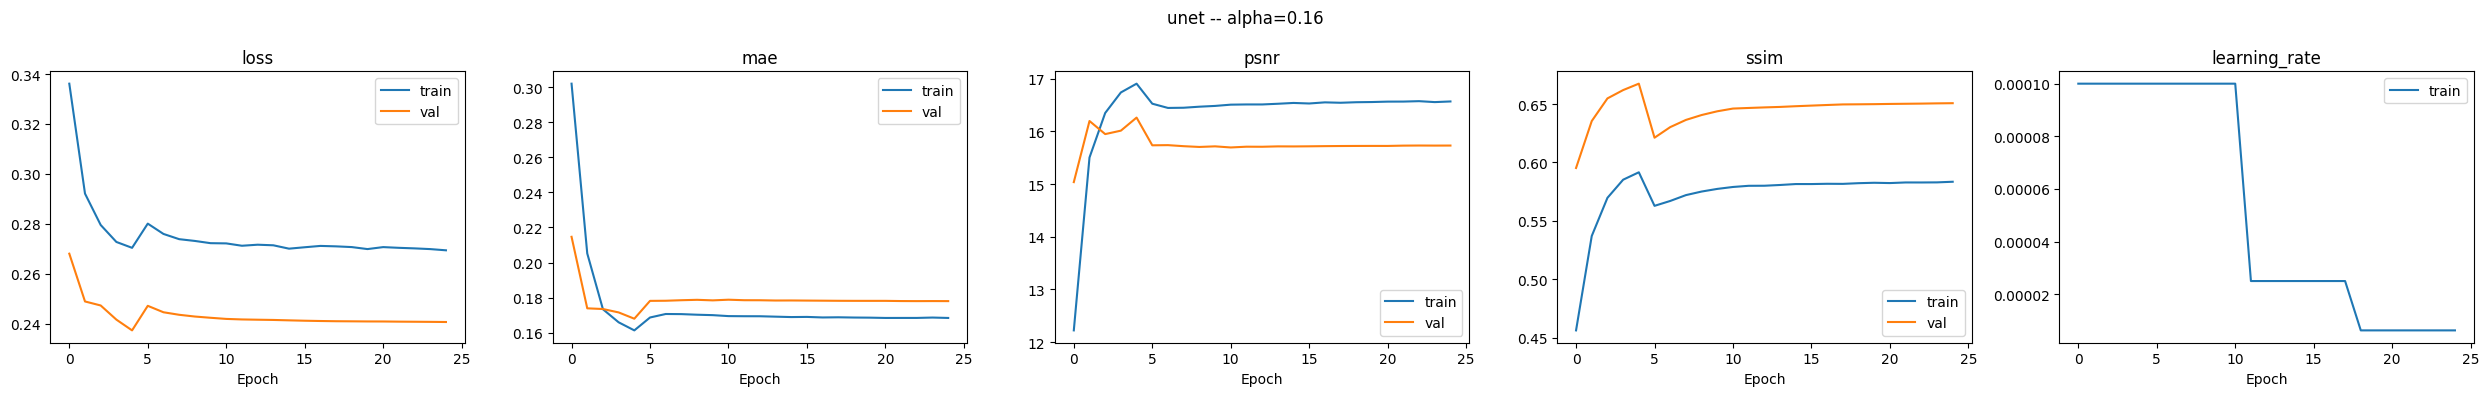

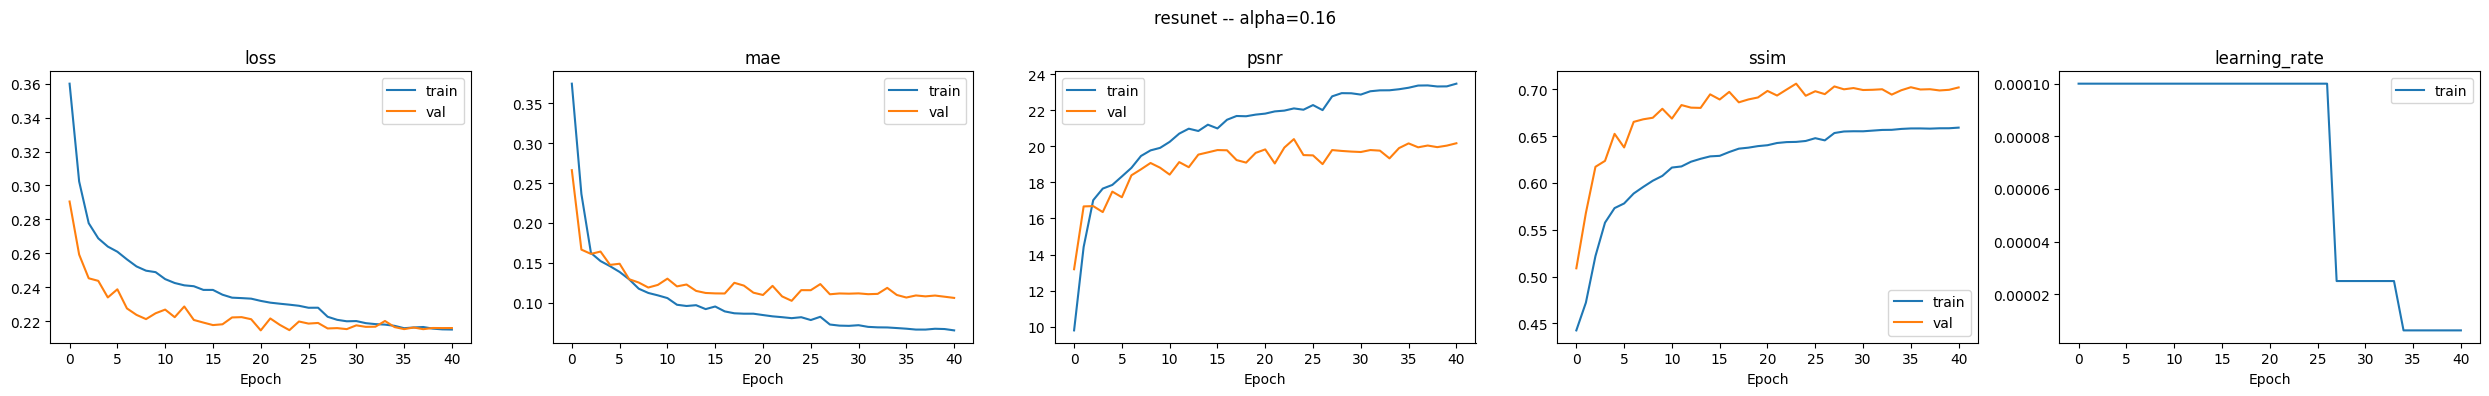

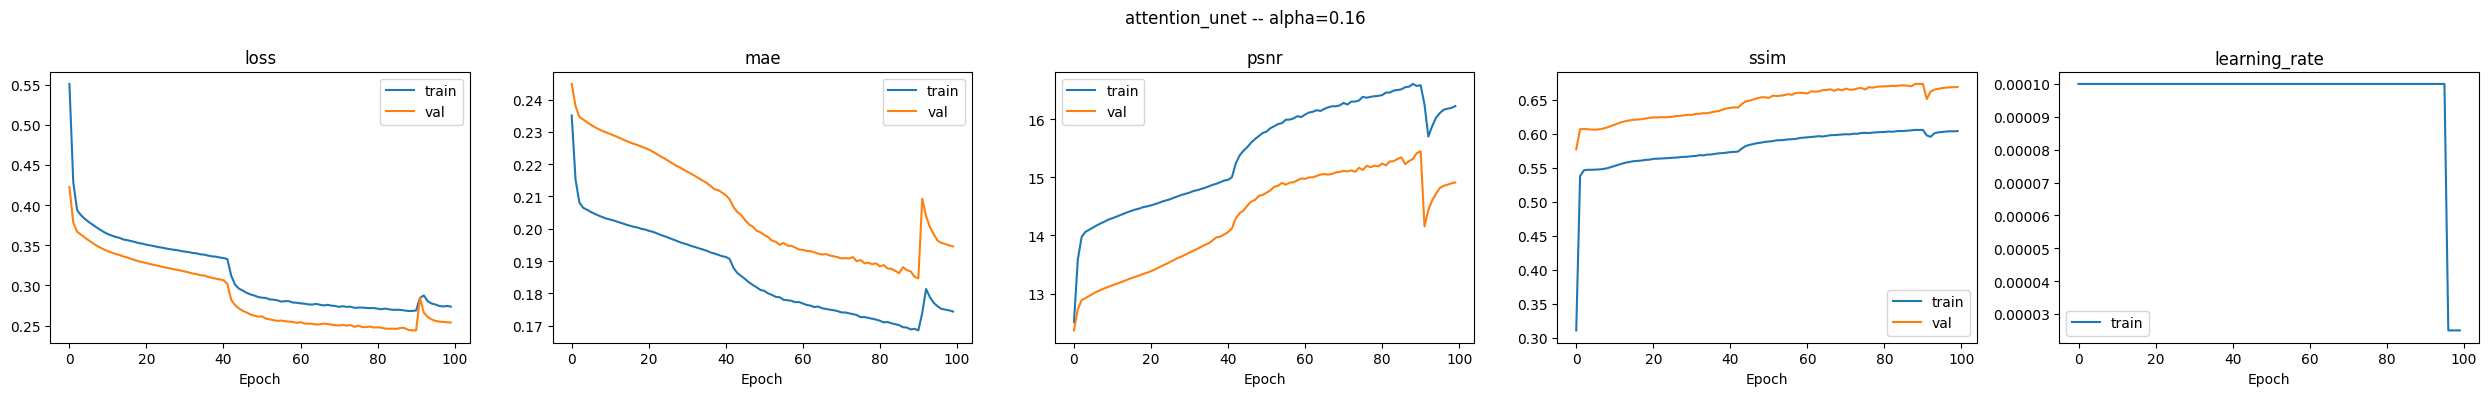

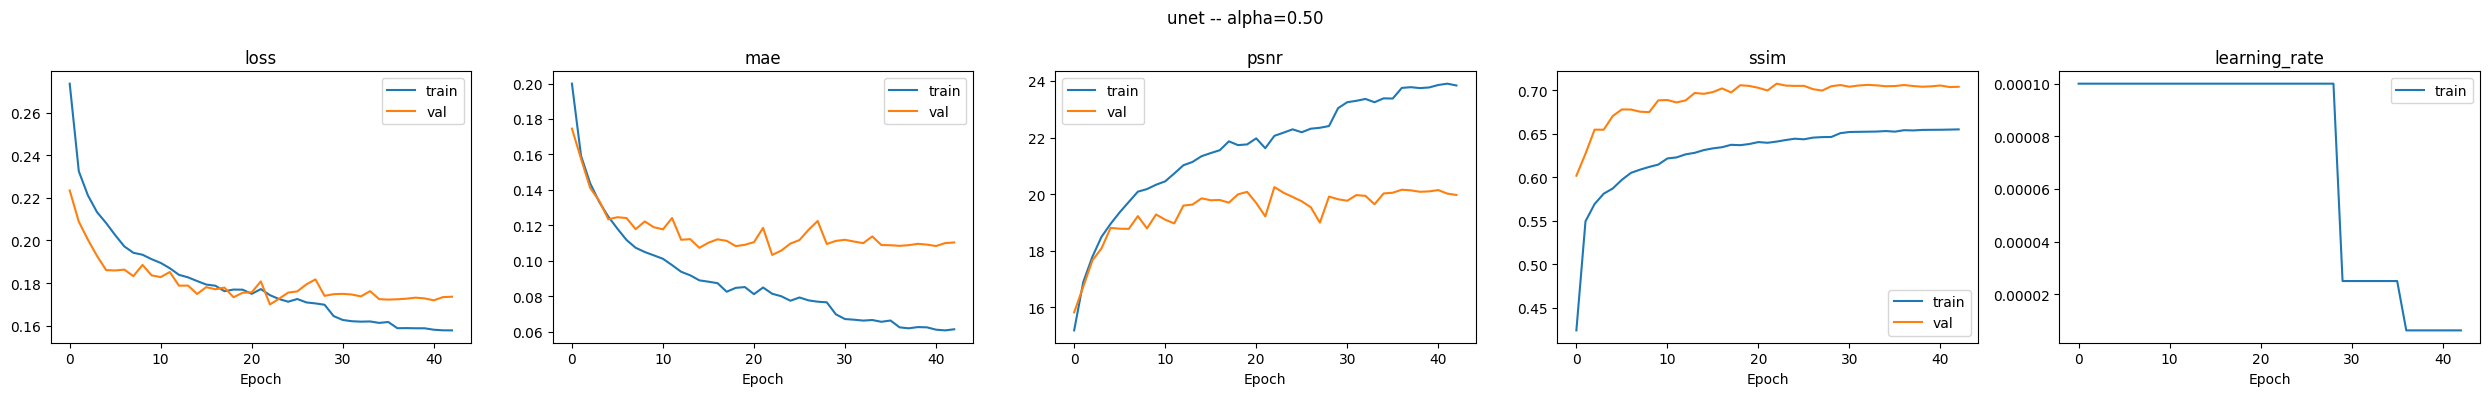

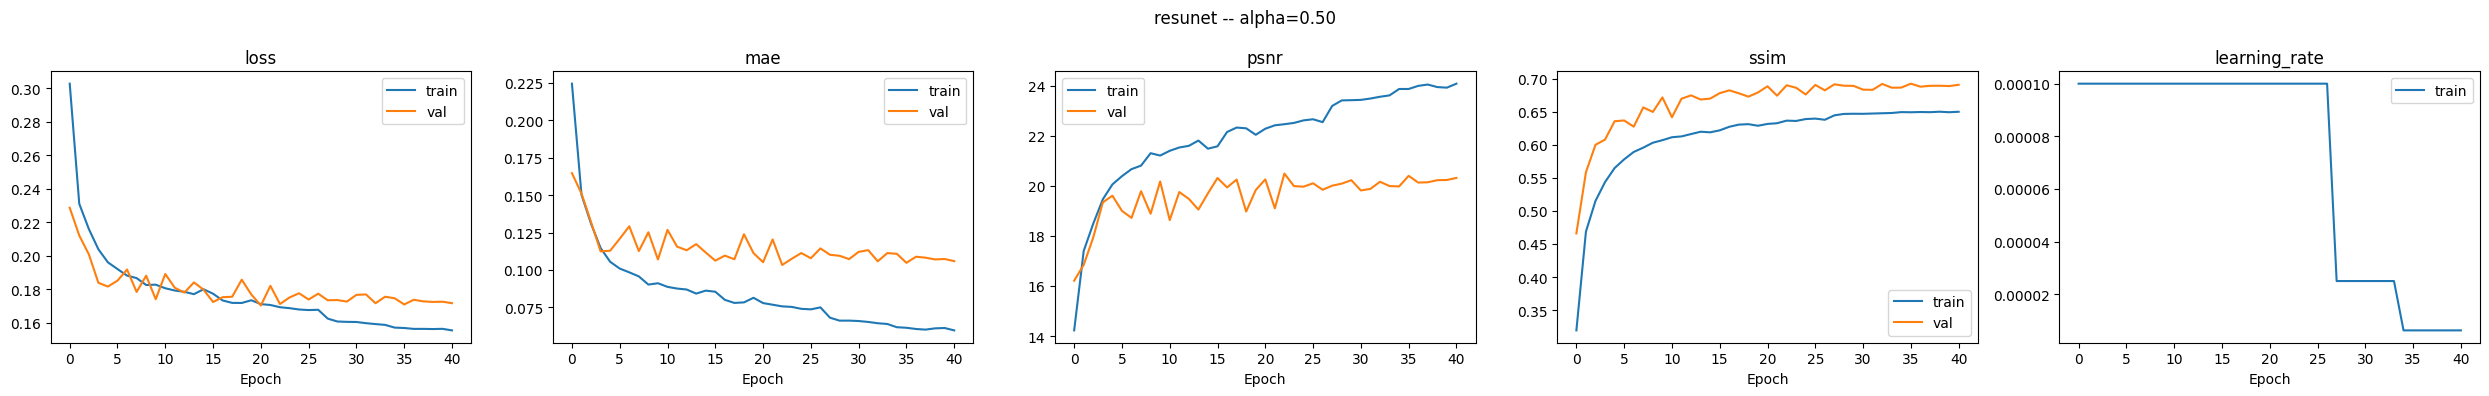

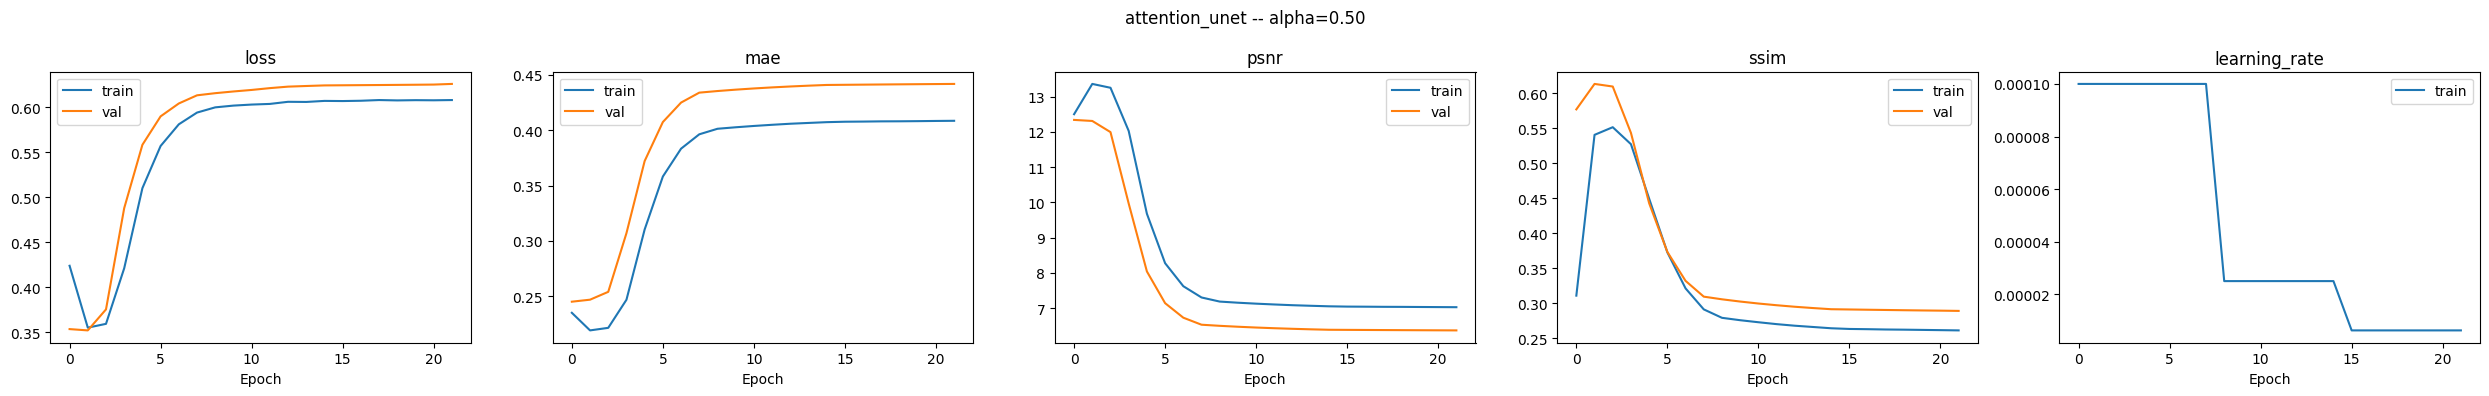

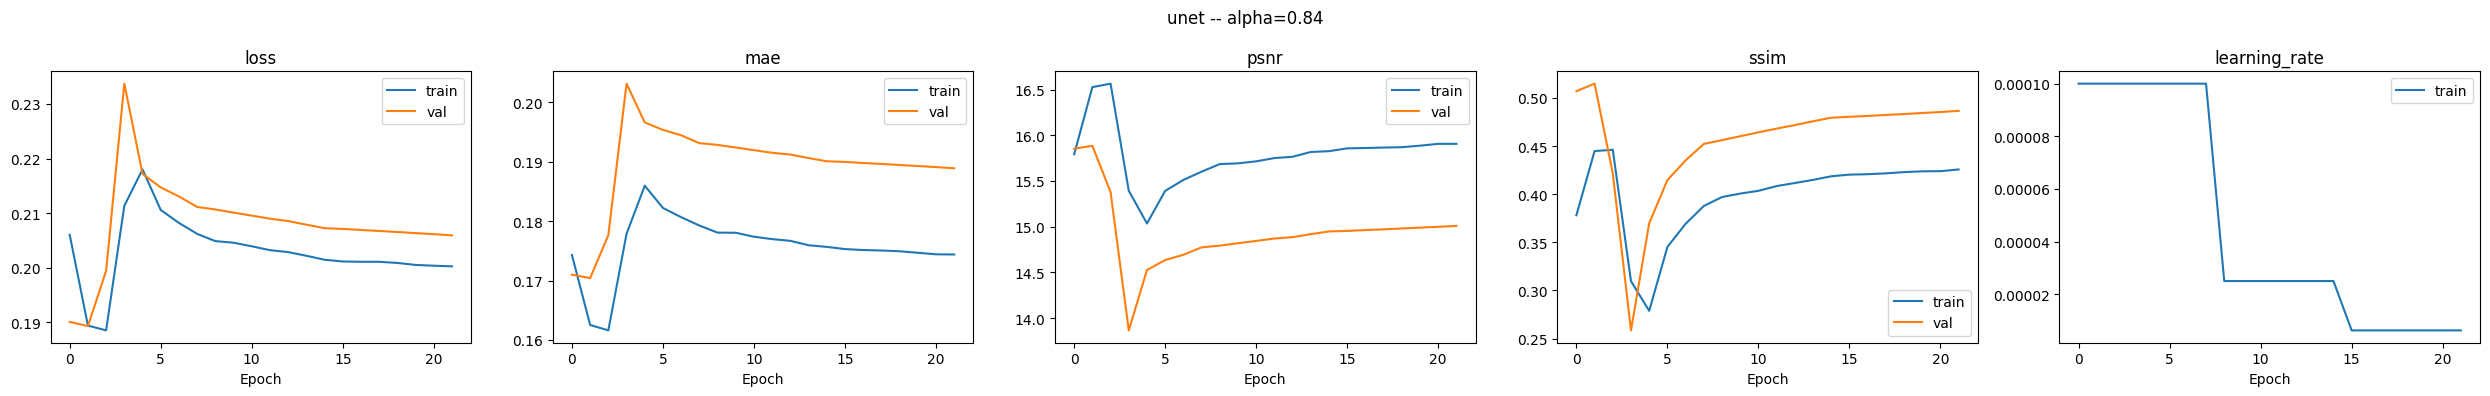

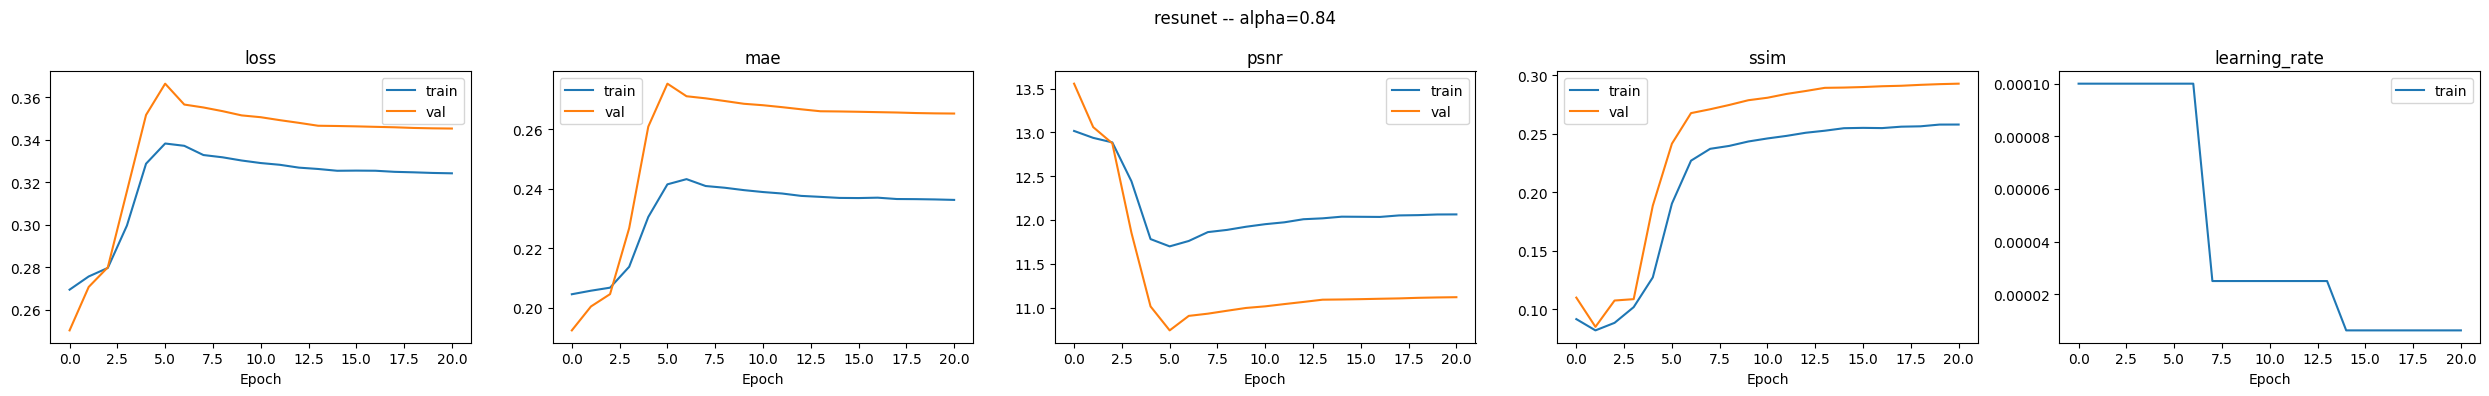

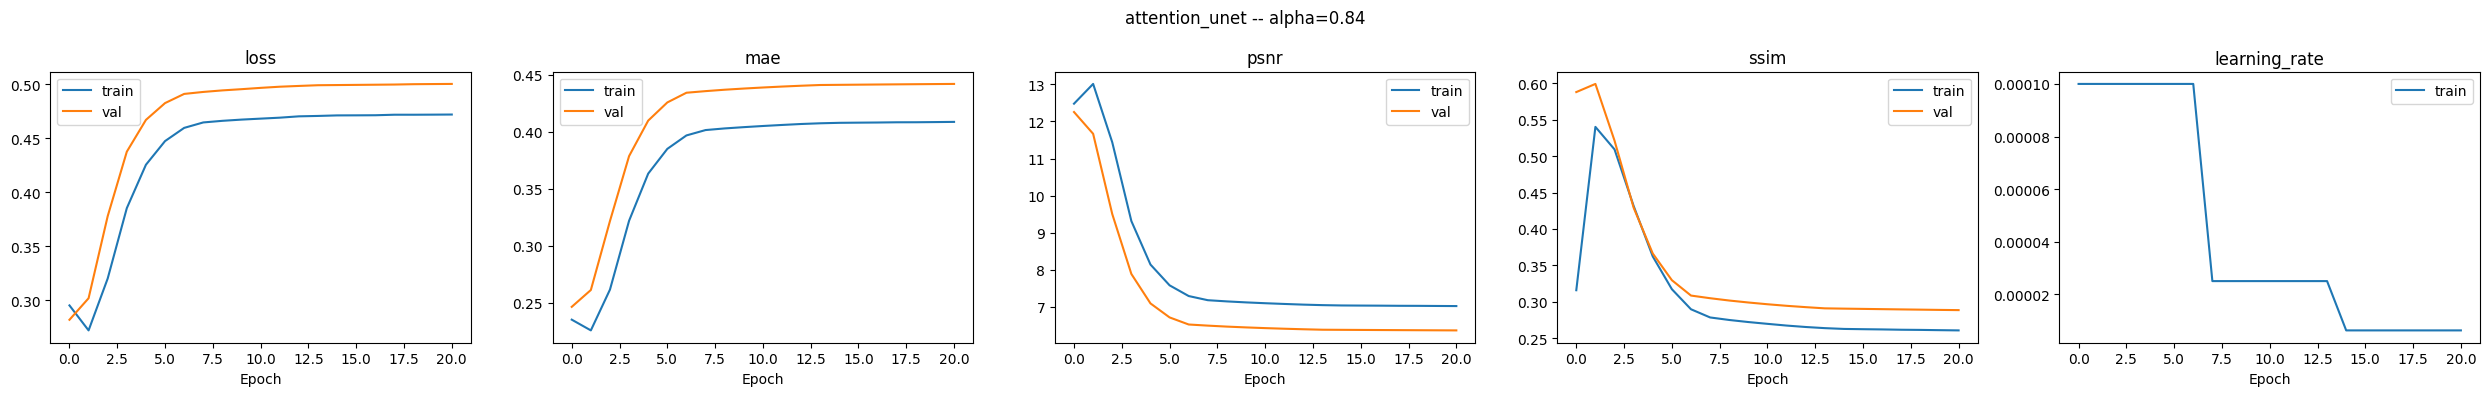

In [6]:
for (arch, alpha), history in histories.items():
    plot_training_curves(history, title=f"{arch} -- alpha={alpha:.2f}")
    plt.show()

## 5. Summary

`val_mae` is reported alongside `val_loss` because, unlike the loss, it does
not carry the alpha weighting and so is comparable across the grid — a
first, fidelity-only read on which alpha trained best. Expect the high-alpha
runs to win on MAE almost by construction; that is not the same as winning
on the deliverable. Rank these checkpoints in `035_evaluation_alpha_sweep.ipynb` (fidelity,
detection AUROC, coherence, per architecture) before drawing any conclusion.

In [7]:
print(f"{'arch':<18}{'alpha':<8}{'ckpt':<9}{'epochs':<8}{'val_loss':<11}{'val_mae':<11}")
print("-" * 71)
for alpha in ALPHAS:
    model_dir, _ = run_dirs(alpha)
    for arch in ARCHS:
        h = histories.get((arch, alpha))
        if h is None:
            print(f"{arch:<18}{alpha:<8.2f}{'MISSING':<9}")
            continue
        print(f"{arch:<18}{alpha:<8.2f}{'found':<9}{len(h['val_loss']):<8}"
              f"{min(h['val_loss']):<11.4f}{min(h['val_mae']):<11.4f}")

print(f"\nCheckpoints under models/alpha_sweep/alpha_<a>/<arch>/ "
      f"(020's models/deterministic/ untouched).")
print(f"Only alpha == settings.LOSS_ALPHA ({settings.LOSS_ALPHA}) is "
      f"loss-comparable to 020's runs.")

arch              alpha   ckpt     epochs  val_loss   val_mae    
-----------------------------------------------------------------------
unet              0.16    found    25      0.2373     0.1679     
resunet           0.16    found    41      0.2146     0.1025     
attention_unet    0.16    found    100     0.2439     0.1847     
unet              0.50    found    43      0.1700     0.1033     
resunet           0.50    found    41      0.1702     0.1033     
attention_unet    0.50    found    22      0.3519     0.2451     
unet              0.84    found    22      0.1893     0.1704     
resunet           0.84    found    21      0.2502     0.1923     
attention_unet    0.84    found    21      0.2821     0.2466     

Checkpoints under models/alpha_sweep/alpha_<a>/<arch>/ (020's models/deterministic/ untouched).
Only alpha == settings.LOSS_ALPHA (0.16) is loss-comparable to 020's runs.
